# End-to-End Machine Learning Pipeline for Tesla Deliveries Prediction

## Objective

The objective of this project is to design and implement an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

In [29]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    TimeSeriesSplit
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Loading Data 

In [30]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()
print(df.shape)
df.info()
df.describe(include="all").T

(2640, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


# Quality Checks on Data
 - Missing Values
 - Duplicate Values

In [31]:
missing = df.isnull().sum()
print("Missing Values :",missing[missing>0])
missing[missing>0]

print("Duplicate Rows :",df.duplicated().sum())

Missing Values : Series([], dtype: int64)
Duplicate Rows : 0


# Data Cleaning 

In [32]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis
 - Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the dataset before building machine learning models.

## Distribution of Estimated Deliveries
This histogram shows the distribution of the target variable (Estimated_Deliveries). It helps identify the most common delivery values, data spread, skewness, and possible outliers.

## Correlation Analysis
The correlation heatmap is used to measure the relationship between numerical variables. Correlation values range from -1 to +1,where +1 indicate a strong positive and -1 indicate a strong negative relationship.

## Outlier Detection
A boxplot is used to identify potential outliers in the Average Price (USD) column. Detecting outliers is important because extreme values can influence machine learning models.

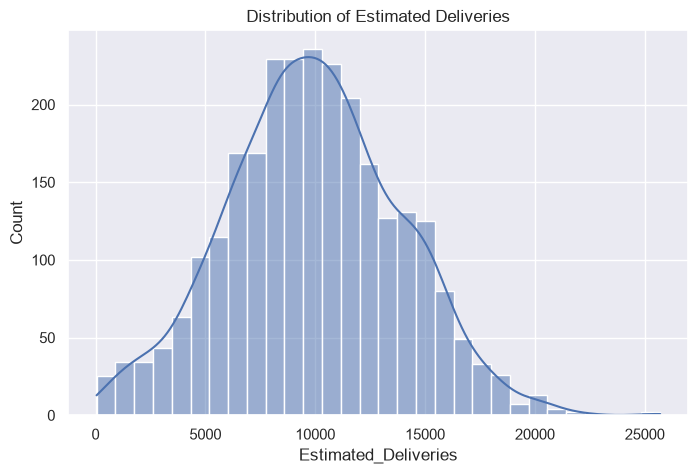

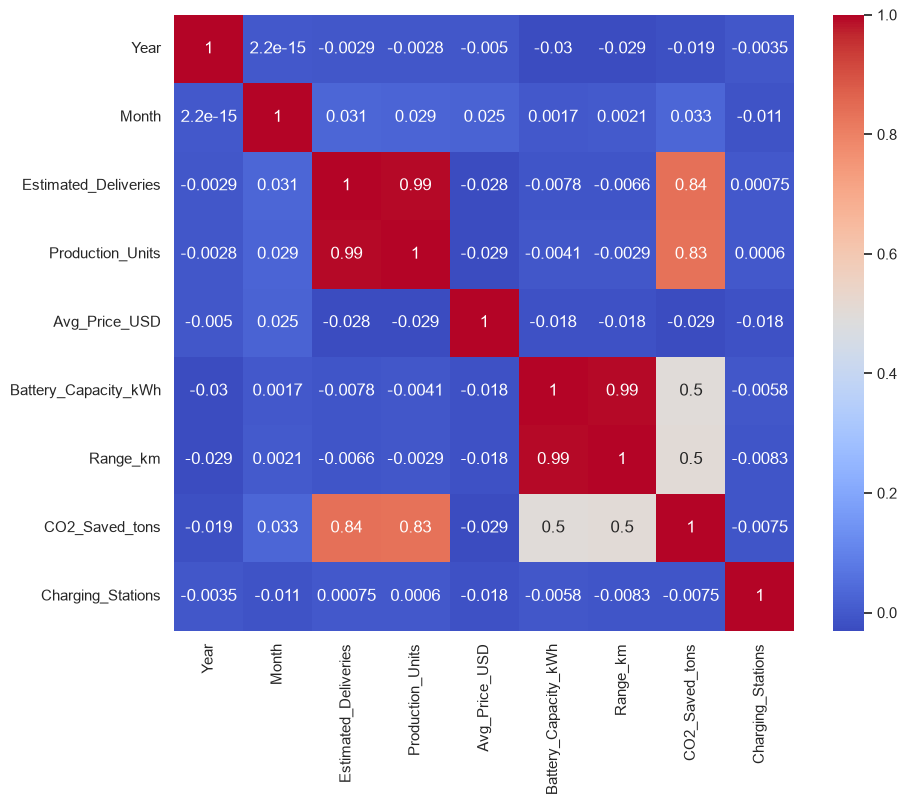

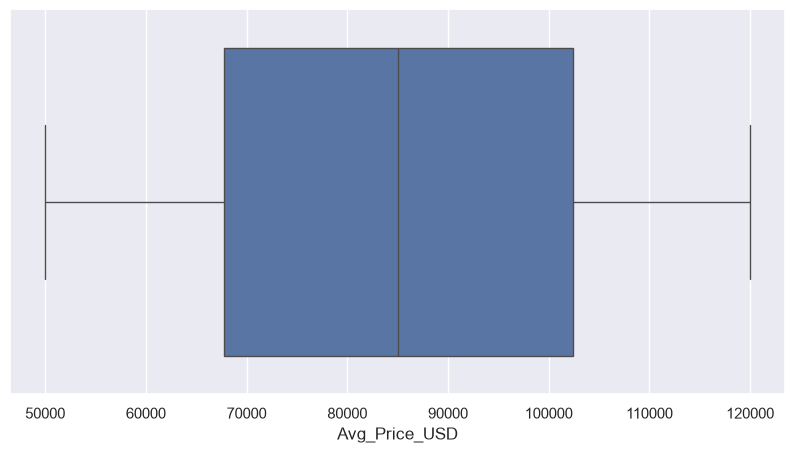

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")


plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)


plt.figure(figsize=(10,5))
sns.boxplot(x=df["Avg_Price_USD"])
plt.show()

# Feature Selection and Data Preprocessing

Before training the machine learning model, the dataset is divided into input features X and the target variable y.

- Features X: Variables used for prediction.
- Target y:Variable that the model will learn to predict.

The preprocessing stage also identifies numerical and categorical features for appropriate transformations.

In [34]:
# Target Variable
target = "Estimated_Deliveries"

# Features and Target
X = df.drop(columns=[target])
y = df[target]

# Identify Numerical and Categorical Features
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

# Preprocessing for Numerical Data
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Preprocessing for Categorical Data
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine Both Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully.")

Categorical Features:
Index(['Region', 'Model', 'Source_Type'], dtype='str')

Numerical Features:
Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='str')

Preprocessing pipeline created successfully.


# Model Building

The preprocessed data is divided into training and testing sets. A Linear Regression model is trained using the preprocessing pipeline. Finally, the model is evaluated using standard regression metrics.

In [35]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

# Create Pipeline
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train Model
linear_pipeline.fit(X_train, y_train)

# Predictions
y_pred = linear_pipeline.predict(X_test)

print("\nModel Training Completed Successfully.")

Training Samples : (2112, 11)
Testing Samples : (528, 11)

Model Training Completed Successfully.


In [36]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Model Performance
MAE  : 309.70
RMSE : 384.03
R² Score : 0.9901


# Ridge and Lasso Regression

Linear Regression may suffer from overfitting when features are highly correlated. Ridge and Lasso are regularized regression techniques that help improve model generalization.

- Ridge Regression (L2 Regularization) reduces the impact of large coefficients.
- Lasso Regression (L1 Regularization) can shrink some coefficients to zero, effectively performing feature selection.

In [37]:
# Ridge Regression Pipeline
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)

# Lasso Regression Pipeline
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_test)

# Function to Evaluate Models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return [name, mae, rmse, r2]

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, y_pred),
    evaluate_model("Ridge Regression", y_test, ridge_pred),
    evaluate_model("Lasso Regression", y_test, lasso_pred)
], columns=["Model", "MAE", "RMSE", "R² Score"])

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,309.703674,384.029115,0.990106
1,Ridge Regression,309.529486,384.068592,0.990104
2,Lasso Regression,309.661353,383.860460,0.990115


### Observation

The performance of Linear, Ridge, and Lasso Regression models is very similar.

All three models achieved an R² score of approximately 0.99, indicating excellent predictive performance.

Since the dataset exhibits strong linear relationships and relatively clean data, applying L1 (Lasso) and L2 (Ridge) regularization does not significantly change the model performance.

Therefore, Linear Regression performs almost as well as the regularized models for this dataset.

# Hyperparameter Tuning

Hyperparameter tuning is performed to find the optimal model parameters that produce the best predictive performance.

GridSearchCV evaluates multiple values of the regularization parameter (alpha) using cross-validation and selects the best-performing model automatically.

In [38]:
# Ridge Hyperparameter Tuning
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train)

# Lasso Hyperparameter Tuning
lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train, y_train)

print("Best Ridge Alpha :", ridge_grid.best_params_)
print("Best Ridge Score :", ridge_grid.best_score_)

print()

print("Best Lasso Alpha :", lasso_grid.best_params_)
print("Best Lasso Score :", lasso_grid.best_score_)

Best Ridge Alpha : {'model__alpha': 0.1}
Best Ridge Score : 0.9902000632042294

Best Lasso Alpha : {'model__alpha': 10}
Best Lasso Score : 0.9902679123018879


# Time Series Forecasting

Time series forecasting is used to analyze historical delivery trends and estimate future values. The monthly average deliveries are calculated and visualized over time. A simple linear regression model is then used to forecast future deliveries based on the historical trend.

Forecast Table (First 20 Test Records):


,Actual,Predicted,Error (%)
0,6991,10123.94,44.81
1,9326,10174.79,9.10
2,9061,9916.97,9.45
3,8951,10007.53,11.80
4,8707,9840.02,13.01
5,11351,9757.44,14.04
6,14193,9817.10,30.83
7,15156,9817.53,35.22
8,9915,10040.49,1.27
9,7642,9806.36,28.32


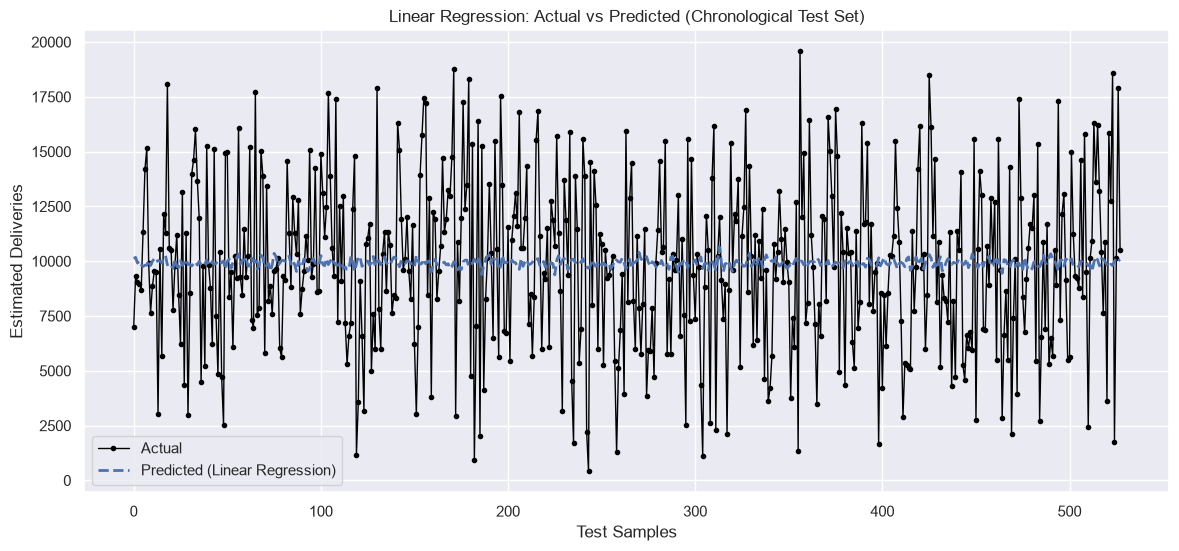

In [39]:
# Time Series Forecasting (Chronological Test Set)

# Forecast Table
forecast_table = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": forecast
})

forecast_table["Error (%)"] = (
    abs(forecast_table["Actual"] - forecast_table["Predicted"])
    / forecast_table["Actual"]
) * 100

forecast_table = forecast_table.round(2)

print("Forecast Table (First 20 Test Records):")
display(forecast_table.head(20))

# Actual vs Predicted Plot
plt.figure(figsize=(14,6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    label="Actual",
    color="black",
    linewidth=1,
    marker="o",
    markersize=3
)

plt.plot(
    range(len(forecast)),
    forecast,
    label="Predicted (Linear Regression)",
    linestyle="--",
    linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted (Chronological Test Set)")
plt.xlabel("Test Samples")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

This project successfully implemented an end-to-end machine learning pipeline using Tesla deliveries and production data.

The workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and forecasting evaluation.

Linear Regression, Ridge Regression, and Lasso Regression achieved excellent predictive performance with an R² score close to 0.99. The forecasting results were evaluated using a chronological test set by comparing actual and predicted deliveries.

Overall, this project demonstrates a complete machine learning workflow from data preparation to model evaluation.